# DQN (Defender) vs. DQN (Attacker) for the Budgeted Attack-Defense Game

In [1]:
# Importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from collections import namedtuple, deque

In [2]:
# Necessary imports for the attack-defense problem
# Assuming 'utils.py' exists in the same directory
from utils import prob_success, attacker_lingo_model 

# Parameters
n_targets = 5 # Number of targets
alpha, beta, A = 1, 1, 0.1
attacker_budget = 5 # Attacker's investment (Million USD)
defender_budget = 30 # Defender's Investment (Million USD)

# Infrastructure valuations for n targets
B = np.array([50, 20, 35, 45, 30]) # Attacker's valuations 
D = np.array([50, 150, 100, 80, 120]) # Defender's valuations

# DQN Parameters
BATCH_SIZE = 64
GAMMA = 0.99 # Discount factor, from original AC update
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 5000
TARGET_UPDATE = 10 # How often to update the target network
BUFFER_CAPACITY = 10000

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# DQN Helper Classes and Functions

def get_all_allocations(n_targets, budget):
    """
    Generates all possible integer allocations of a budget across n_targets.
    """
    # This is equivalent to combinations with replacement
    # We use a recursive helper function
    
    allocs = []
    def find_allocs_recursive(remaining_budget, current_alloc, target_index):
        if target_index == n_targets - 1:
            # Last target gets whatever is left
            current_alloc.append(remaining_budget)
            allocs.append(tuple(current_alloc))
            current_alloc.pop()
            return

        for i in range(remaining_budget + 1):
            current_alloc.append(i)
            find_allocs_recursive(remaining_budget - i, current_alloc, target_index + 1)
            current_alloc.pop()

    find_allocs_recursive(budget, [], 0)
    
    # Convert tuples to tensors
    alloc_tensors = [torch.tensor(alloc, dtype=torch.float32) for alloc in allocs]
    return alloc_tensors

# Replay Memory
Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# DQN Network
class QNetwork(nn.Module):
    def __init__(self, n_targets, n_actions, hidden_size=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, n_actions)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        return self.fc2(x)

In [4]:
# DQN Agent Class (for Attacker)

class DQNAgent:
    def __init__(self, n_targets, budget, lr=1e-3):
        self.n_targets = n_targets
        self.budget = budget
        self.gamma = GAMMA
        
        # Get all possible allocation actions
        self.allocations = get_all_allocations(n_targets, budget)
        self.n_actions = len(self.allocations)
        # Move allocations to device for easy lookup
        self.allocations_tensor = torch.stack(self.allocations).to(device)
        
        self.q_network = QNetwork(n_targets, self.n_actions).to(device)
        self.target_network = QNetwork(n_targets, self.n_actions).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval() # Target net is only for inference
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayBuffer(BUFFER_CAPACITY)
        self.steps_done = 0

    def get_allocation(self, state):
        """
        Get budget allocation using epsilon-greedy policy.
        Returns the allocation tensor and the index of the action.
        """
        eps_threshold = EPS_END + (EPS_START - EPS_END) * \
                        math.exp(-1. * self.steps_done / EPS_DECAY)
        self.steps_done += 1
        
        if random.random() > eps_threshold:
            # Exploit: get best action from Q-network
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.q_network(state_tensor)
                action_index = q_values.max(1)[1].item()
        else:
            # Explore: pick a random action
            action_index = random.randrange(self.n_actions)
            
        allocation = self.allocations_tensor[action_index]
        return allocation, action_index

    def push_to_memory(self, state, action_index, reward, next_state):
        """Pushes a transition to the replay buffer"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        action_tensor = torch.tensor([[action_index]], device=device, dtype=torch.long)
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
        
        self.memory.push(state_tensor, action_tensor, reward_tensor, next_state_tensor)

    def learn(self):
        """Update Q-network from a batch of transitions"""
        if len(self.memory) < BATCH_SIZE:
            return

        transitions = self.memory.sample(BATCH_SIZE)
        # Transpose the batch
        batch = Transition(*zip(*transitions))

        # Concatenate the batch elements
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        next_state_batch = torch.cat(batch.next_state)
        
        # Note: In this specific problem, the state doesn't change,
        # so state_batch and next_state_batch are the same.
        # But we follow the standard DQN update logic as the AC agent
        # also used a gamma and next_state.

        # Q(s, a) - The Q-value for the action taken
        state_action_values = self.q_network(state_batch).gather(1, action_batch)

        # V(s') = max_a' Q_target(s', a')
        # We use target_network for stability.
        next_state_values = self.target_network(next_state_batch).max(1)[0].detach()
        
        # Expected Q-value: R + gamma * V(s')
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch

        # Compute loss (Mean Squared Error)
        loss = F.mse_loss(state_action_values, expected_state_action_values.unsqueeze(1))
        
        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        # Clip gradients (optional but good practice)
        # for param in self.q_network.parameters():
        #     param.grad.data.clamp_(-1, 1)
        self.optimizer.step()

In [5]:
class AttackDefenseGame:
    def __init__(self, n_targets, attacker_budget, defender_budget):
        self.n_targets = n_targets
        self.attacker_budget = attacker_budget
        self.defender_budget = defender_budget
        
        # Initialize state (could be target values, vulnerabilities, etc.)
        self.state = np.ones(n_targets)
    
    def get_rewards(self, attacker_allocation, defender_allocation):
        """
        Compute rewards based on allocations using contest success function.
        Leave blank for user to implement.
        
        Args:
            attacker_allocation: torch.Tensor of shape (n_targets,)
            defender_allocation: torch.Tensor of shape (n_targets,)
        
        Returns:
            attacker_reward: float
            defender_reward: float
        """
        prob_successes = [prob_success(Ti=Ti,Gi=Gi, alpha=alpha, beta=beta, Ai=A) 
                         for Ti,Gi in zip(attacker_allocation,defender_allocation)]
        
        attacker_reward = np.dot(B, prob_successes)
        defender_reward = -1 * np.dot(D, prob_successes)
        
        return attacker_reward, defender_reward
    
    def step(self, attacker_allocation, defender_allocation):
        """Execute one step of the game"""
        attacker_reward, defender_reward = self.get_rewards(
            attacker_allocation, defender_allocation
        )
        
        # State can be updated based on game dynamics
        next_state = self.state.copy()
        
        return next_state, attacker_reward, defender_reward

## With Attacker (DQN) and Defender (DQN)

In [7]:
# Training
n_episodes = 10000

game = AttackDefenseGame(n_targets, attacker_budget, defender_budget)
attacker = DQNAgent(n_targets, attacker_budget, lr=1e-3)
defender = DQNAgent(n_targets, defender_budget, lr=1e-3)

# To record for plots
attacker_gains = []
defender_losses = []

print(f"Attacker (DQN) action space size: {attacker.n_actions}")
print(f"Defender (DQN) action space size: {defender.n_actions}") # Added for symmetry

for episode in range(n_episodes):
    state = game.state
    
    # Get allocations from both agents
    # Attacker (DQN) uses epsilon-greedy
    attacker_allocation, attacker_action_index = attacker.get_allocation(state)
    # Defender (DQN) uses epsilon-greedy
    defender_allocation, defender_action_index = defender.get_allocation(state)
    
    # Execute game step
    # We pass .cpu() as the game step expects numpy or cpu tensors
    next_state, attacker_reward, defender_reward = game.step(
        attacker_allocation.cpu(), defender_allocation.cpu()
    )
    
    # Update Attacker (DQN)
    # 1. Push to memory
    attacker.push_to_memory(state, attacker_action_index, attacker_reward, next_state)
    # 2. Perform learning step
    attacker.learn()
    
    # Update Defender (DQN)
    # 1. Push to memory
    defender.push_to_memory(state, defender_action_index, defender_reward, next_state)
    # 2. Perform learning step
    defender.learn()
    
    # Update target network for both DQN agents
    if episode % TARGET_UPDATE == 0:
        attacker.target_network.load_state_dict(attacker.q_network.state_dict())
        defender.target_network.load_state_dict(defender.q_network.state_dict())
    
    if episode % 100 == 0:
        # Get deterministic/greedy policies for logging
        state_tensor_dev = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Attacker's greedy action
            best_action_idx = attacker.q_network(state_tensor_dev).max(1)[1].item()
            log_attacker_alloc = attacker.allocations_tensor[best_action_idx]
        
            # Defender's greedy action
            best_defender_action_idx = defender.q_network(state_tensor_dev).max(1)[1].item()
            log_defender_alloc = defender.allocations_tensor[best_defender_action_idx]

        # Get rewards for these greedy policies
        _, log_attacker_reward, log_defender_reward = game.step(
            log_attacker_alloc.cpu(), log_defender_alloc.cpu() # Added .cpu()
        )

        attacker_gains.append(log_attacker_reward)
        defender_losses.append(-1 * log_defender_reward)

        print(f"Episode {episode}: Attacker Reward (Greedy) = {log_attacker_reward:.2f}, "
              f"Defender Reward (Greedy) = {log_defender_reward:.2f}")
        
        # These prints are fine, they show the *sampled* actions from the loop
        print(f" Sampled Attacker allocation: {attacker_allocation.detach().cpu().numpy()}")
        print(f" Sampled Defender allocation: {defender_allocation.detach().cpu().numpy()}")

Attacker (DQN) action space size: 126
Defender (DQN) action space size: 46376
Episode 0: Attacker Reward (Greedy) = 26.44, Defender Reward (Greedy) = -58.63
 Sampled Attacker allocation: [1. 0. 2. 0. 2.]
 Sampled Defender allocation: [ 5.  1. 21.  3.  0.]
Episode 100: Attacker Reward (Greedy) = 22.90, Defender Reward (Greedy) = -68.46
 Sampled Attacker allocation: [2. 1. 1. 1. 0.]
 Sampled Defender allocation: [ 3.  1.  2.  0. 24.]
Episode 200: Attacker Reward (Greedy) = 53.09, Defender Reward (Greedy) = -112.14
 Sampled Attacker allocation: [0. 0. 2. 2. 1.]
 Sampled Defender allocation: [ 3. 11.  8.  5.  3.]
Episode 300: Attacker Reward (Greedy) = 51.62, Defender Reward (Greedy) = -147.89
 Sampled Attacker allocation: [0. 0. 2. 2. 1.]
 Sampled Defender allocation: [ 6. 18.  1.  4.  1.]
Episode 400: Attacker Reward (Greedy) = 58.04, Defender Reward (Greedy) = -123.79
 Sampled Attacker allocation: [0. 0. 2. 2. 1.]
 Sampled Defender allocation: [ 7.  1.  5. 11.  6.]
Episode 500: Attacker

In [8]:
print("Average over final 100 episodes")
print("Attacker Gains", np.mean(attacker_gains[-100:]))
print("Defender Losses", np.mean(defender_losses[-100:]))

Average over final 100 episodes
Attacker Gains 44.95173245966434
Defender Losses 111.85077094361186


In [11]:
print(attacker_gains)

[26.441105641424656, 22.900560200214386, 53.08732461184263, 51.620460003614426, 58.03625889122486, 21.941915415227413, 47.01216474175453, 53.57931546866894, 49.88432452082634, 17.627741619944572, 22.049342170357704, 32.123825401067734, 40.44926144182682, 35.90692788362503, 37.73604214191437, 47.74114914238453, 56.417153254151344, 50.0748236477375, 31.440047398209572, 28.992972262203693, 49.96242567896843, 33.78161333501339, 37.87939563393593, 71.32014527916908, 29.278426095843315, 40.819378197193146, 25.304455533623695, 90.47619640827179, 30.902094319462776, 43.34837593138218, 48.59075792133808, 39.248237535357475, 24.017086029052734, 22.470898032188416, 35.07625304162502, 18.324075117707253, 39.12744864821434, 45.807591881603, 30.124374702572823, 51.039203107357025, 31.398075595498085, 34.96275760233402, 35.18065944314003, 33.67372926324606, 76.35558813810349, 44.60776500403881, 53.48641648888588, 35.85824005305767, 25.103885233402252, 46.578140035271645, 46.489102467894554, 25.355581

In [12]:
print(defender_losses)

[58.62794414162636, 68.46174538135529, 112.14225307106972, 147.8885018825531, 123.79218012094498, 54.62970271706581, 129.45532083511353, 162.97698855400085, 154.6478521823883, 50.65436363220215, 59.81543928384781, 86.91720843315125, 139.3226632475853, 97.72607266902924, 96.96870028972626, 128.17799925804138, 120.55396884679794, 120.09688675403595, 70.36813050508499, 87.86325454711914, 135.3829389810562, 89.51802134513855, 133.71480584144592, 164.23602640628815, 74.45027679204941, 138.17752093076706, 81.73541158437729, 228.57144355773926, 84.29420292377472, 143.02838802337646, 156.31747394800186, 134.55504298210144, 54.49025094509125, 60.2050706744194, 85.4030504822731, 44.11107271909714, 96.4616996049881, 110.36958739161491, 51.57486766576767, 78.47935140132904, 114.27310734987259, 98.51517133414745, 85.31778857111931, 74.64682206511497, 206.24461010098457, 165.06395429372787, 150.11141270399094, 96.19410641491413, 82.4273444712162, 149.612724930048, 117.30650156736374, 62.011079639196

Text(0.5, 0, 'Episodes')

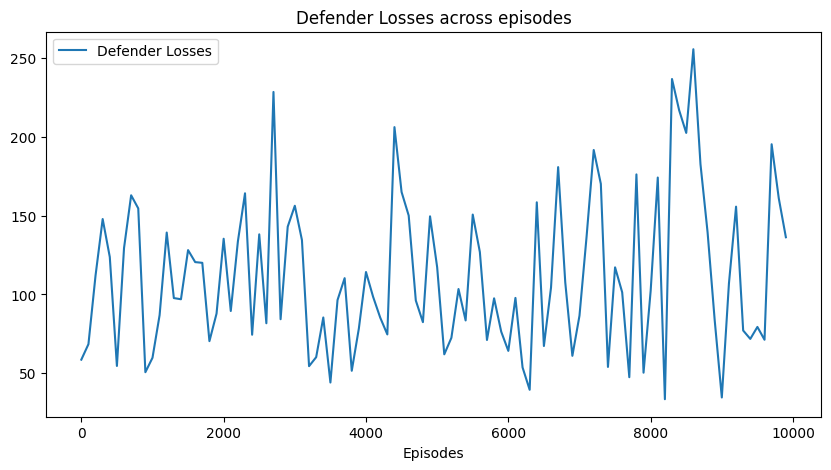

In [9]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),defender_losses, label='Defender Losses')
plt.legend()
plt.title("Defender Losses across episodes")
plt.xlabel("Episodes")

Text(0.5, 0, 'Episodes')

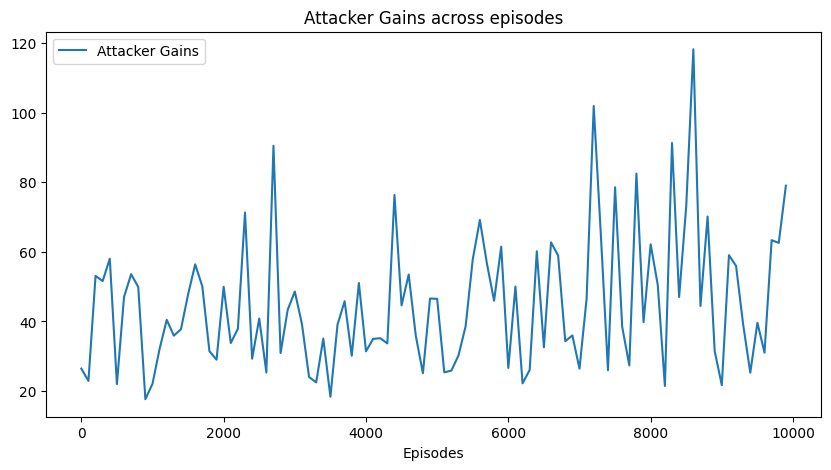

In [10]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),attacker_gains, label='Attacker Gains')
plt.legend()
plt.title("Attacker Gains across episodes")
plt.xlabel("Episodes")